# From a histogram to a pdf

With sampling algorithms such as Metropolis or Gibbs MCMC we can obtain samples from a distribution $p(\cdot)$. If we obtain sufficient samples, their distribution approximates $p(\cdot)$. We can see this if we visualize the histogram and the true probability density function simultaneously - they have (approximately) the same shape. But how can we use a histogram to give us the probability density of a specific value of a parameter? 

First, we define $x\sim \mathcal{N}(\mu, \sigma^2)$, with $\mu=5$ and $\sigma=1$. Let's start by plotting the true function (which in reality we would not know!):

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st

from matplotlib import rc
rc('font',**{'family':'serif','serif':['Palatino']})
rc('text', usetex=True)

plt.rc('axes', titlesize=30)        # fontsize of the axes title
plt.rc('axes', labelsize=24)        # fontsize of the x and y labels
plt.rc('xtick', labelsize=18)       # fontsize of the tick labels
plt.rc('ytick', labelsize=18)       # fontsize of the tick labels
plt.rc('legend', fontsize=20)       # legend fontsize
plt.rc('figure', titlesize=36)      # fontsize of the figure title

Text(0, 0.5, '$p(x\\mid \\mu, \\sigma)$')

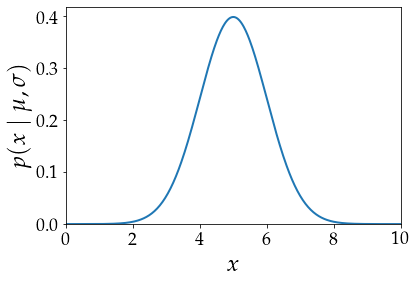

In [2]:
mu = 5.0
sigma = 1.0

# The true function, which in practice we would not know!
# Since we are working on a discrete machine (i.e. a computer), we plot the true function at specific pts:
x_range = np.linspace(0, 10, num=500)
norm_pdf = st.norm.pdf(x_range, loc=mu, scale=np.sqrt(sigma))

plt.figure()
ax = plt.gca()
ax.plot(x_range, norm_pdf, lw=2)
ax.set_xlim([0, 10])
ax.set_ylim(bottom=0)
ax.set_xlabel('$x$')
ax.set_ylabel('$p(x\mid \mu, \sigma)$')


If we didn't know this function (and we couldn't solve it using e.g. a conjugate prior), we would have to approximate it. We could use a grid approximation, or obtain samples $x$ from this distribution via MCMC, but since the Gaussian distribution is well known, we'll just sample from it directly using `numpy.random.normal`. Remember that in real problems it wouldn't be so easy!

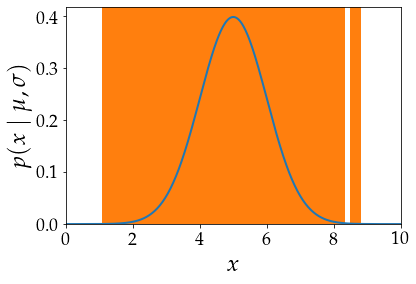

In [18]:
# Draw samples from a N(5,1) distribution
n = 10000
x_samples = np.random.normal(loc=mu, scale=sigma, size=n)


plt.figure()
ax = plt.gca()
ax.plot(x_range, norm_pdf, lw=2)
ax.set_xlim([0, 10])
ax.set_ylim(bottom=0)
ax.set_xlabel('$x$')
ax.set_ylabel('$p(x\mid \mu, \sigma)$')
_ = ax.hist(x_samples, bins=50)

Hmm that doesn't look right! We are plotting a histogram of _counts_ on top of a probability density function. These two things have completely different units, so we cannot see their similarity in such a plot. 

We want the histogram to approximate the distribution, but for that we need to _normalize_ it by dividing the histogram counts by (the number of observations $\times$ the width of the histogram bins), so that its total area becomes 1.

Luckily, PyPlot can do this for us all at once, using `density=True`. However, the same idea is also shown in the other Python notebook example on grid approximations.

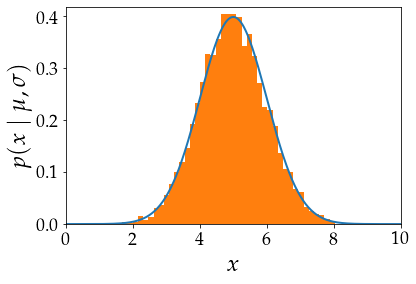

In [19]:
plt.figure()
ax = plt.gca()
ax.plot(x_range, norm_pdf, lw=2)
ax.set_xlim([0, 10])
ax.set_ylim(bottom=0)
ax.set_xlabel('$x$')
ax.set_ylabel('$p(x\mid \mu, \sigma)$')
normalized_counts, bin_edges, _ = ax.hist(x_samples, bins=50, density=True)

After normalization, the total area of the histogram should be (approximately) 1.Let's check that below. Don't forget that we need to adjust for the width of the bins!

In [20]:
bin_width = bin_edges[1] - bin_edges[0]
print(np.sum(normalized_counts) * bin_width)

0.9999999999999994


That'll do!

To find the (approximate) probability density of a specific value for $x$, we have to check in which bin that value lies:

True p(x=3.96 | mu, sigma) = 0.23
Approximate p(x=3.96 | mu, sigma) = 0.24


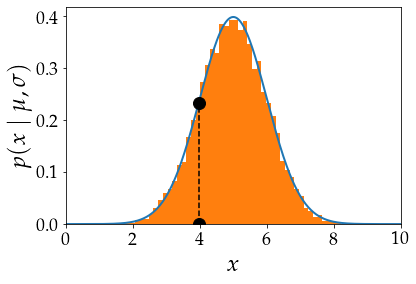

In [6]:
# Pick one value at random
x_value = np.random.rand()*6+2
true_pdf_at_x = st.norm.pdf(x_value, loc=mu, scale=np.sqrt(sigma))


plt.figure()
ax = plt.gca()
ax.plot(x_range, norm_pdf, lw=2)
ax.set_xlim([0, 10])
ax.set_ylim(bottom=0)
ax.set_xlabel('$x$')
ax.set_ylabel('$p(x\mid \mu, \sigma)$')
normalized_counts, bin_edges, _ = ax.hist(x_samples, bins=50, density=True)
ax.plot([x_value, x_value], [0, true_pdf_at_x], ls='--', c='k', marker='o', ms=12)


# Find the bin in which this value for x is:
bin_of_x_value = np.where(x_value < bin_edges)[0][0]-1
# Get the corresponding normalized count:
approximate_pdf_at_x = normalized_counts[bin_of_x_value]


print('True p(x={:0.2f} | mu, sigma) = {:0.2f}'.format(x_value, true_pdf_at_x))
print('Approximate p(x={:0.2f} | mu, sigma) = {:0.2f}'.format(x_value, approximate_pdf_at_x))


## Kernel density estimation

In practical useage of MCMC, we often want to query the posterior distribution that we have approximated with MCMC samples. This can be done with the approach above, but that can be a bit noisy depending on how many samples we have collected and what our bin size is. A more robust approach fits a smooth function to the histogram, while ensuring its integral is 1. This approach is known as _kernel density estimation_. 

Its use is demonstrated in the code block below. See that if you increase $n$, the approximation improves.

True p(x=6.10 | mu, sigma) = 0.22
Approximate p(x=6.10 | mu, sigma) = 0.22


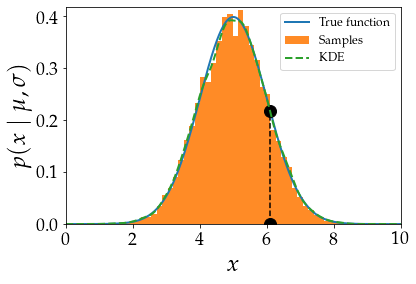

In [24]:
# Import the Gaussian kernel density estimator. Don't be fooled by the name! 
# The term Gaussian refers to how this approach smooths the histogram, not with 
# the probability density function we are using.
from scipy.stats import gaussian_kde

# Pick one value
x_value = 6.1
true_pdf_at_x = st.norm.pdf(x_value, loc=mu, scale=np.sqrt(sigma))

n = 10000
x_samples = np.random.normal(loc=mu, scale=sigma, size=n)

kde_p = gaussian_kde(x_samples)

plt.figure()
ax = plt.gca()
ax.plot(x_range, norm_pdf, lw=2, label='True function')
ax.set_xlim([0, 10])
ax.set_ylim(bottom=0)
ax.set_xlabel('$x$')
ax.set_ylabel('$p(x\mid \mu, \sigma)$')
ax.hist(x_samples, bins=50, density=True, label='Samples', alpha=0.9)
ax.plot([x_value, x_value], [0, true_pdf_at_x], ls='--', c='k', marker='o', ms=12)

ax.plot(x_range, kde_p(x_range), lw=2, ls='--', label='KDE')
ax.legend(fontsize=12)

print('True p(x={:0.2f} | mu, sigma) = {:0.2f}'.format(x_value, true_pdf_at_x))
print('Approximate p(x={:0.2f} | mu, sigma) = {:0.2f}'.format(x_value, kde_p(x_value).item()))

Kernel density estimation can be used to fit a probability density function to any collection of samples, but it makes an assumption: that the function should be smooth. If there are clear regions where this is not the case (for instance, the probability distribution covers only positive numbers - then around 0 the function is not smooth!), then the technique might fail. 